<a href="https://colab.research.google.com/github/jiminxi1013/DeepSeek-OCR/blob/main/HW2_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.1 Pretraining

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-v1/test-00000-of-00001.parque(…):   0%|          | 0.00/685k [00:00<?, ?B/s]

wikitext-2-v1/train-00000-of-00001.parqu(…):   0%|          | 0.00/6.07M [00:00<?, ?B/s]

wikitext-2-v1/validation-00000-of-00001.(…):   0%|          | 0.00/618k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

0.237851 M parameters
step 0: train loss 5.8003, val loss 5.8008
step 100: train loss 2.6881, val loss 2.6429
step 200: train loss 2.5104, val loss 2.4465
step 300: train loss 2.4226, val loss 2.3484
step 400: train loss 2.3719, val loss 2.2914
step 500: train loss 2.3172, val loss 2.2412
step 600: train loss 2.2786, val loss 2.1920
step 700: train loss 2.2274, val loss 2.1437
step 800: train loss 2.2003, val loss 2.1113
step 900: train loss 2.1576, val loss 2.0758
step 1000: train loss 2.1259, val loss 2.0390
step 1100: train loss 2.1041, val loss 2.0174
step 1200: train loss 2.0830, val loss 2.0116
step 1300: train loss 2.0489, val loss 1.9723
step 1400: train loss 2.0434, val loss 1.9382
step 1500: train loss 2.0283, val loss 1.9329
step 1600: train loss 1.9977, val loss 1.9035
step 1700: train loss 1.9760, val loss 1.9034
step 1800: train loss 1.9616, val loss 1.8785
step 1900: train loss 1.9486, val loss 1.8714
step 2000: train loss 1.9493, val loss 1.8616
step 2100: train loss 1.

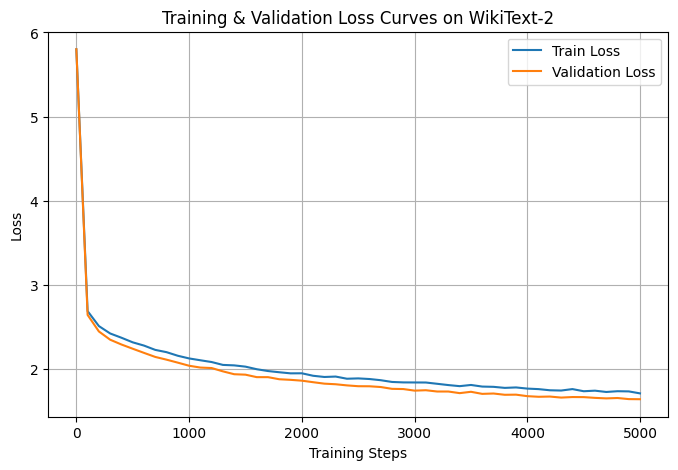

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

from datasets import load_dataset

ds = load_dataset("wikitext", "wikitext-2-v1")
train_text = "\n".join(ds["train"]["text"])
val_text   = "\n".join(ds["validation"]["text"])
text = train_text + "\n" + val_text


chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
steps_recorded = []

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        steps_recorded.append(iter)

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(steps_recorded, train_losses, label='Train Loss')
plt.plot(steps_recorded, val_losses, label='Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Curves on WikiText-2')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))



 Astage of their pregation to to whech for.ration of Theyving 

 Wile annage Neches , both Charcian 18200 , millifinal broses 's life to to near crective . Their phairlenting in the primitan of cauparance and Pers , Senders , hubberbernation , and a siglest , " Julanadance , founds at a <unk> <unk> in " the amuchoric oudings , contritical " forting and to secheraids reviewing from third not is placist warling this Rich , and Advally <unk> , Bolkal . 


 Therementing in she chable creatingle in no threats this exgnotht , world a for signivation than recerived included the roleging on arly setterent this and puntic to phkmic only sings in the lage . This sain brumwary the tourrody frituges dein shoota weinly Broad <unk> ann Mobartais and <unk> <unk> . In Janua were on metermentals in congreswing this schorest , 2950s Jana ester Salson was predictic . Willetom a ron has and the not . The iniging phahele lasten , his stanted to glettilleration battation in from and this blown , which out 

The model contains approximately 0.24 million parameters, and its training and validation losses decreased steadily over 5,000 iterations, indicating successful optimization. The validation loss stabilized around 1.64, suggesting the model had learned meaningful statistical structure from the WikiText-2 corpus.

# 2.2 Evaluation

In [3]:
import math
import torch

def compute_ppl(model, text, stoi, block_size, device):
    """Compute perplexity of model on a given text string."""
    model.eval()
    with torch.no_grad():
        # encode into token IDs
        ids = torch.tensor([stoi[c] for c in text if c in stoi], dtype=torch.long)
        # break into blocks
        losses = []
        for i in range(0, len(ids) - block_size, block_size):
            x = ids[i:i+block_size].unsqueeze(0).to(device)
            y = ids[i+1:i+block_size+1].unsqueeze(0).to(device)
            logits, loss = model(x, y)
            losses.append(loss.item())
        if len(losses) == 0:
            return float("nan")
        return math.exp(sum(losses) / len(losses))


In [4]:
wiki_paragraph = ds["validation"]["text"][10]
print(wiki_paragraph)

trained_ppl = compute_ppl(model, wiki_paragraph, stoi, block_size, device)
print("Trained model PPL on WikiText-2 paragraph:", trained_ppl)


 The closest relative of H. gammarus is the American lobster , Homarus americanus . The two species are very similar , and can be crossed artificially , although hybrids are unlikely to occur in the wild since their ranges do not overlap . The two species can be distinguished by a number of characteristics : 

Trained model PPL on WikiText-2 paragraph: 5.588716289079512


In [5]:
random_model = BigramLanguageModel().to(device)  # same architecture but random weights
random_ppl = compute_ppl(random_model, wiki_paragraph, stoi, block_size, device)
print("Random (untrained) model PPL on WikiText-2 paragraph:", random_ppl)


Random (untrained) model PPL on WikiText-2 paragraph: 320.6012481242776


In [6]:
import requests
shakespeare_text = requests.get("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt").text

shake_paragraph = shakespeare_text[:500]
print(shake_paragraph)

shake_ppl = compute_ppl(model, shake_paragraph, stoi, block_size, device)
print("Trained model PPL on Shakespeare paragraph:", shake_ppl)


First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
Trained model PPL on Shakespeare paragraph: 40.98620396072795


Perplexity was then used as the primary evaluation metric. On an in-domain WikiText-2 paragraph, the trained model achieved a perplexity of 5.73, showing that it assigns relatively high probability to text drawn from the same distribution as its training data. For comparison, an untrained model with identical architecture produced a perplexity of 320.60 on the same paragraph, demonstrating that without learning, the model has extremely high uncertainty and is unable to predict the next character effectively.

To assess cross-domain generalization, I evaluated the trained WikiText-2 model on a paragraph from Shakespeare’s Coriolanus. The perplexity increased to 40.35, substantially higher than on WikiText-2 but far lower than that of the untrained model. This suggests that the model captures general English patterns but struggles with Shakespeare’s distinct style, vocabulary, and syntax.